# Markov chain ensembles using ReCom

Reference: PA_recom.ipynb from Prof. Veomett's AI for redistricting

## Initialization

In [1]:
import random
random.seed(12345678)

In [2]:
import matplotlib.pyplot as plt
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom
from gerrychain.tree import bipartition_tree
from functools import partial
import pandas as pd
import geopandas as gpd
import csv
import os
import datetime  #For keeping track of runtime
import tqdm # for progress bar

In [3]:
outdir="../data/AZ_recom_2020_CD/"

Here are some parameters that we can change later if we'd like. <br>
```save_district_plot_mod``` determines which plots (maps) we'll save.

In [4]:
total_steps_in_run=10001
save_plot_mod=1000

In [5]:
os.makedirs(outdir, exist_ok=True)
graph = Graph.from_file("../data/AZ_shapefile/AZ.shp")

In [6]:
elections = [
    Election("G20PRE", {"Democratic": "G20PRED", "Republican": "G20PRER"}),
    Election("G20USS", {"Democratic": "G20USSD", "Republican": "G20USSR"}),
]


In [7]:
my_updaters = {"population": updaters.Tally("TOTPOP", alias="population")}

In [8]:
election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

In [9]:
initial_partition = GeographicPartition(graph, 
                                        assignment= "SEND",
                                        updaters=my_updaters)

## Setting up the Markov Chain

In [10]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

In [11]:
proposal_recom = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.02,
                   node_repeats=2,
                  )

In [12]:
method=partial(bipartition_tree,  # Use bipartition_tree method
                allow_pair_reselection=True  # Enable pair reselection
                )

In [18]:
proposal = partial(proposal_recom, method=method)

In [14]:
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)

In [15]:
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.10)

In [19]:
chain = MarkovChain(
    proposal=proposal,
    constraints=[
        pop_constraint,
        compactness_bound
    ],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
    )

## Running the chain

In [22]:
# Store the partitions in the chain
partitions = [partition for partition in chain.with_progress_bar()]

100%|██████████████████████████████████████████████████████████████████████████| 500/500 [1:23:29<00:00, 10.02s/it]


### The presidential

#### Efficiency gap

In [23]:
from gerrychain.metrics.partisan import efficiency_gap

In [24]:
data_pre_eg = [efficiency_gap(partition['G20PRE']) for partition in partitions]

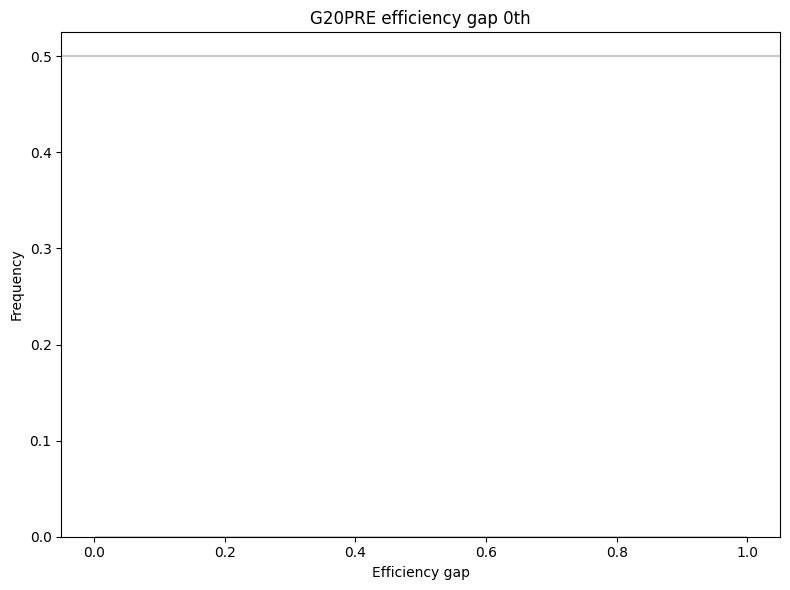

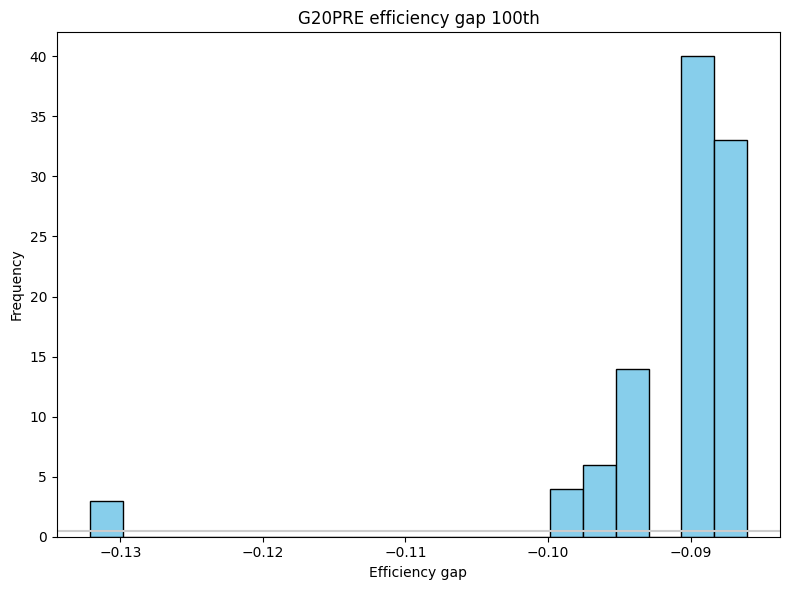

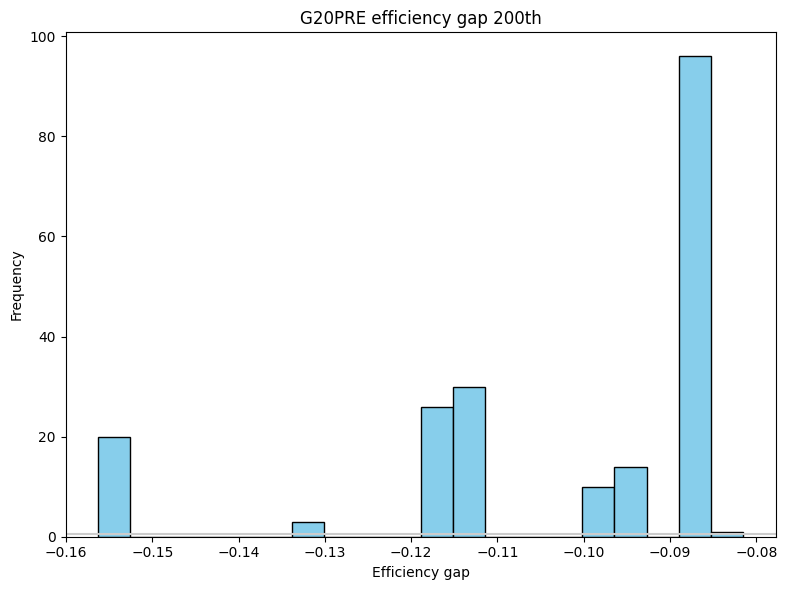

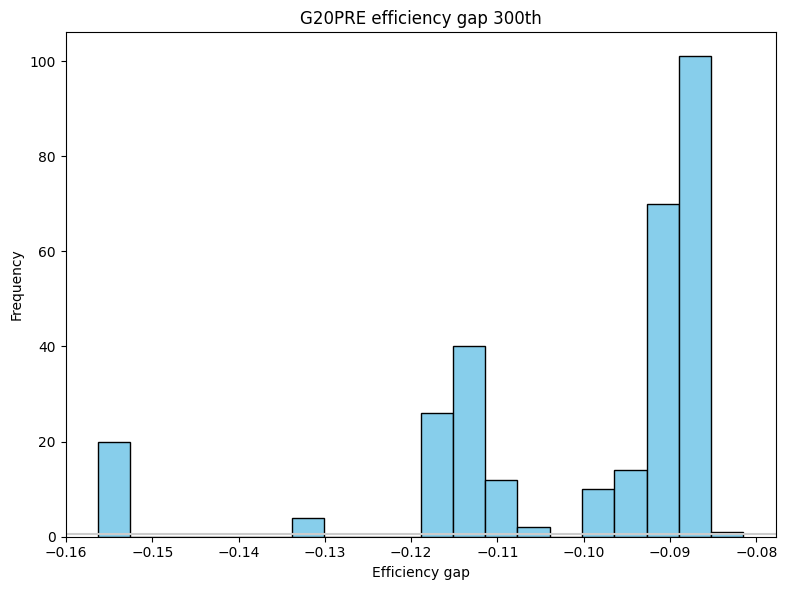

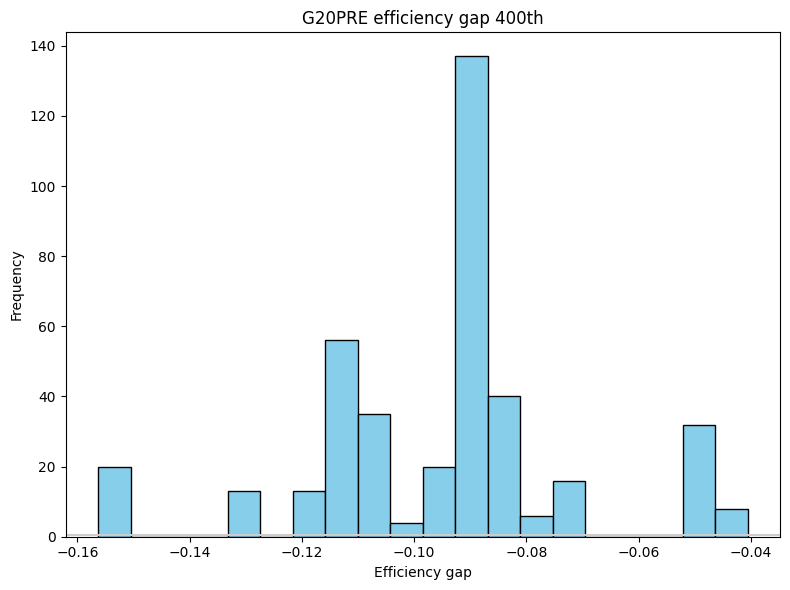

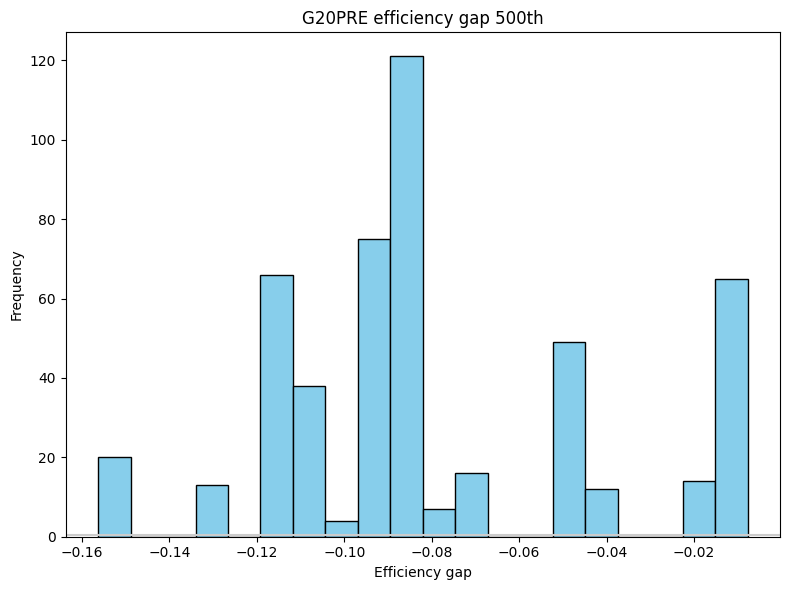

In [48]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_pre_eg[:i], bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20PRE efficiency gap " + str(i) + "th")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Efficiency gap")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, 'AZ_G20PRE_eg_' + str(i) + '.png'))
    plt.show()

#### Dem-won districts

In [31]:
data_pre_dw = [partition['G20PRE'].seats("Democratic") for partition in partitions]
data_pre_dw[:10]

[14, 14, 14, 14, 14, 14, 14, 14, 14, 14]

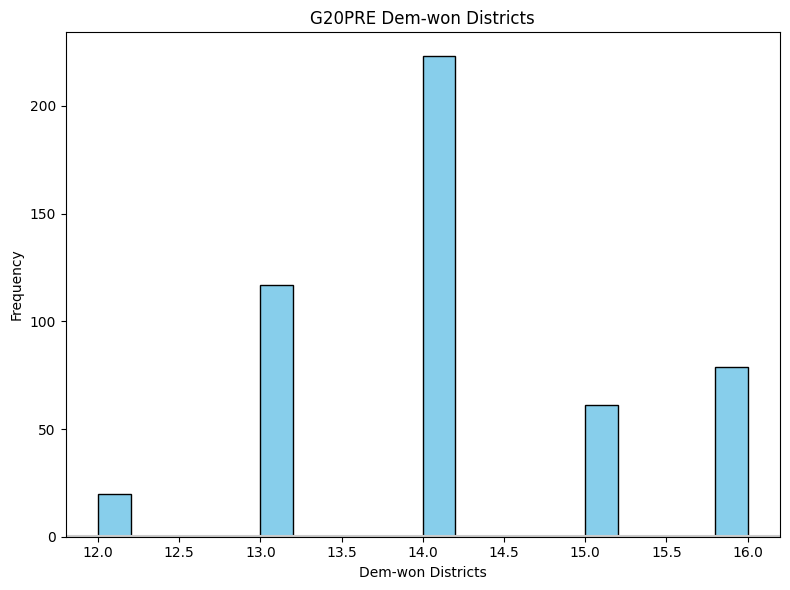

In [34]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_pre_dw[:i], bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20PRE Dem-won Districts " + str(i) + "th")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Dem-won Districts")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, 'AZ_G20PRE_dw_' + str(i) + '.png'))
    plt.show()

#### Cut edges

In [55]:
data_pre_ce = [len(partition.cut_edges) for partition in partitions]
data_pre_ce[:10]

[869, 876, 879, 882, 879, 875, 875, 881, 887, 880]

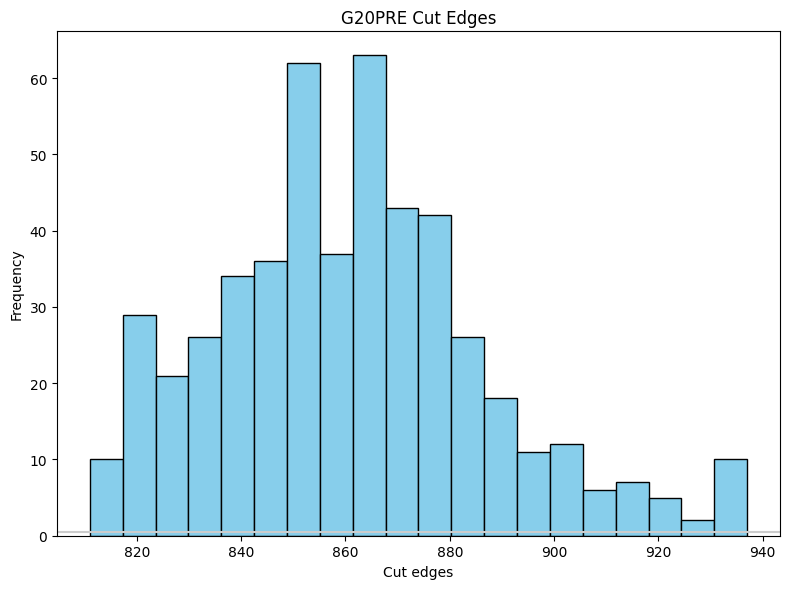

In [37]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6), tight_layout=True)
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_pre_ce, bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20PRE Cut Edges " + str(i) + 'th')
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Cut edges")
    plt.savefig(os.path.join(outdir, 'AZ_G20PRE_ce_' + str(i) + '.png'))
    plt.show()

#### Marginal box (signature of gerrymandering)

In [56]:
data_pre_mb = pd.DataFrame(sorted(partition["G20PRE"].percents("Democratic")) for partition in partitions)
data_pre_mb.iloc[0]

0     0.243283
1     0.351466
2     0.363652
3     0.370096
4     0.378971
5     0.379645
6     0.386194
7     0.391502
8     0.397433
9     0.421393
10    0.438947
11    0.456744
12    0.477461
13    0.477560
14    0.491370
15    0.499222
16    0.515288
17    0.527291
18    0.573395
19    0.592191
20    0.623439
21    0.641409
22    0.644133
23    0.661656
24    0.667399
25    0.676156
26    0.698976
27    0.701200
28    0.760921
29    0.761978
Name: 0, dtype: float64

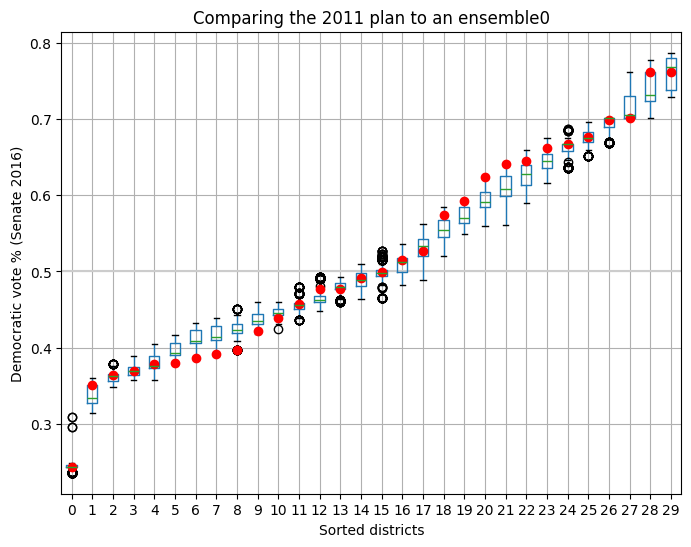

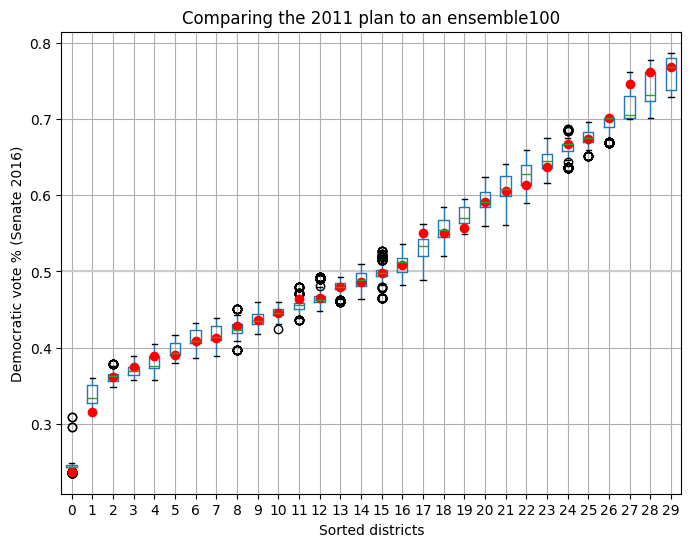

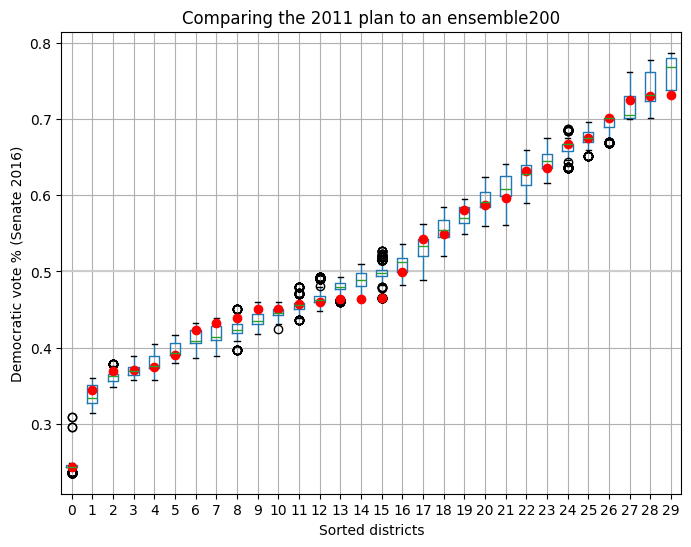

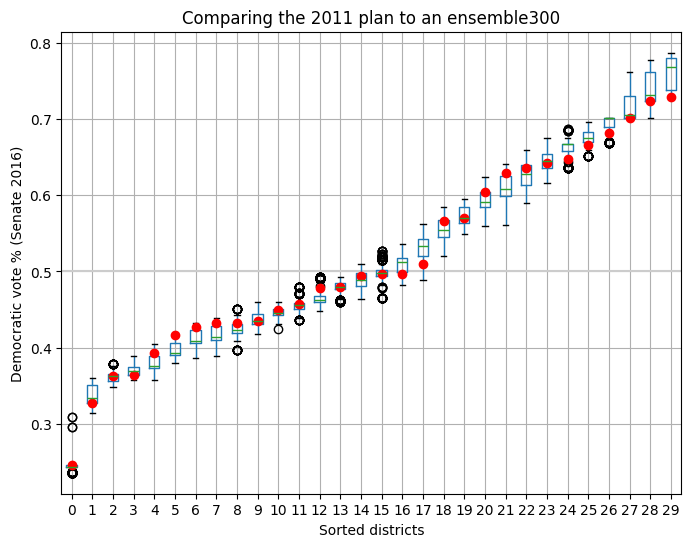

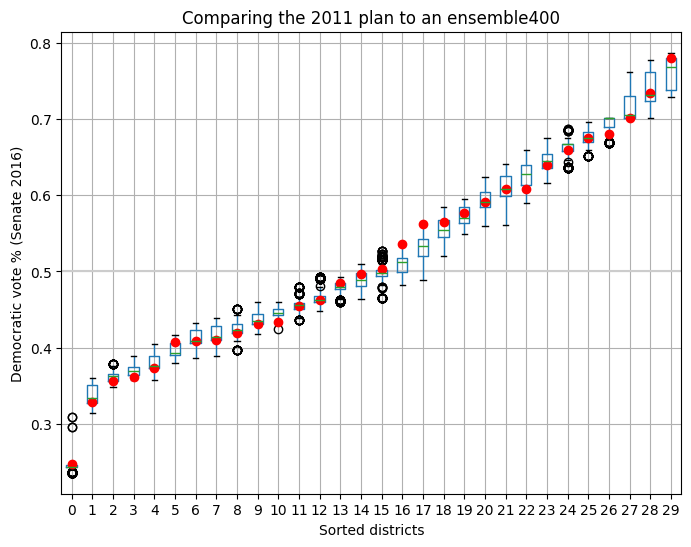

In [61]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw boxplot
    data_pre_mb.boxplot(ax=ax, positions=range(len(data_pre_mb.columns)))
    
    # Draw initial plan's Democratic vote %s (.iloc[0] gives the first row, which corresponds to the initial plan)
    plt.plot(data_pre_mb.iloc[i], "ro")
    
    # Annotate
    ax.set_title("Comparing the G20PRE plan to an ensemble " + str(i) + 'th')
    ax.set_ylabel("Democratic vote % (G20PRE)")
    ax.set_xlabel("Sorted districts")
    plt.savefig('AZ_boxplot_pre_' + str(i) + '.png')
    plt.show()

### U.S. Senate

#### Efficiency gap

In [ ]:
data_uss_eg = [efficiency_gap(partition['G20USS']) for partition in partitions]

In [ ]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_uss_eg[:i], bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20USS efficiency gap " + str(i) + "th")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Efficiency gap")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, 'AZ_G20USS_eg_' + str(i) + '.png'))
    plt.show()

#### Dem-won districts

In [ ]:
data_uss_dw = [partition['G20USS'].seats("Democratic") for partition in partitions]
data_uss_dw[:10]

In [ ]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_uss_dw[:i], bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20USS Dem-won Districts " + str(i) + "th")
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Dem-won Districts")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, 'AZ_G20USS_dw_' + str(i) + '.png'))
    plt.show()

#### Cut edges

In [ ]:
data_uss_ce = [len(partition.cut_edges) for partition in partitions]
data_uss_ce[:10]

In [ ]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6), tight_layout=True)
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw histogram
    ax.hist(data_uss_ce, bins=20, color='skyblue', edgecolor='black')
    
    # Annotate
    ax.set_title("G20USS Cut Edges " + str(i) + 'th')
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Cut edges")
    plt.savefig(os.path.join(outdir, 'AZ_G20USS_ce_' + str(i) + '.png'))
    plt.show()

#### Marginal box (signature of gerrymandering)

In [ ]:
data_uss_mb = pd.DataFrame(sorted(partition["G20USS"].percents("Democratic")) for partition in partitions)
data_uss_mb.iloc[0]

In [ ]:
for i in range(0, len(partitions) + 1, save_plot_mod):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    
    # Draw boxplot
    data_uss_mb.boxplot(ax=ax, positions=range(len(data_uss_mb.columns)))
    
    # Draw initial plan's Democratic vote %s (.iloc[0] gives the first row, which corresponds to the initial plan)
    plt.plot(data_uss_mb.iloc[i], "ro")
    
    # Annotate
    ax.set_title("Comparing the G20USS plan to an ensemble " + str(i) + 'th')
    ax.set_ylabel("Democratic vote % (G20USS)")
    ax.set_xlabel("Sorted districts")
    plt.savefig('AZ_boxplot_uss_' + str(i) + '.png')
    plt.show()